In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.spatial.distance import squareform  
from skimage.measure import regionprops_table
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
endo_genes = ["CDH5", "PECAM1", "VWF", "KDR", "FLT1", "PDGFB"]
fibro_genes = ["PDGFRB", "COL1A1", "COL1A2"]
genes = ['CDH5', 'MMP1', 'COL1A1', 'KDR', 'VWF', 'PECAM1', 'VEGFA', 'DLL4', 'ITGA6', 'SEMA3F', 'JAG1', 'FLT1', 'PDGFB', 'COL1A2', 'APLN', 'PDGFRB', 'ANGPT2', 'ICAM1']
all_data = pd.read_csv("clean_data_with_assigned_cell_type.csv")


## 1. Pairwise gene interactions

Which genes switch on together, and which are mutually exclusive? For every pair we
build a 2x2 on/off table, compute the odds ratio, and test it with **Fisher's exact
test** (Benjamini-Hochberg FDR).

- **Global (full population).** All 18 genes across **every** cell, including the all-0
  cells (split into lineages by the confident ratio) and the unknown-lineage cells.
  This asks which genes co-occur in the population as a whole. Note that the many
  both-off cells inflate positive odds ratios (the empty bottom-right corner of the
  2x2), so the global map is best read for *relative* structure, not absolute effect
  sizes.
- **Within lineage (confident cells only).** Splitting on `cell_type` and then testing
  two *marker* genes is circular - the markers helped define the lineage. Instead of
  leave-two-out, we restrict each lineage to its **confident** cells (>=2 of that
  lineage's markers and **none** of the other lineage's). Cross-lineage pairs (e.g.
  `COL1A1` inside endothelial) are then all-zero -> not testable, so the cross-lineage
  artefact cannot arise.
  - **Caveat (collider bias).** Selecting on ">=2 of a lineage's markers" makes *those
    markers* artificially anti-correlate within the subset (Berkson's paradox). So a
    pair where **both** genes are that lineage's defining markers is not interpretable -
    most visible for fibroblast, where "2 of 3" forces `COL1A1`/`COL1A2`/`PDGFRB` to
    look mutually exclusive. We therefore **flag and exclude defining-marker pairs** and
    read only the non-marker pairs (e.g. `APLN`-`ANGPT2`, `MMP1`-`DLL4` in endothelial),
    which carry no such bias.



In [9]:
# Pairwise gene co-occurrence via Fisher's exact test.
# log2 OR > 0 -> genes cooccur more than expected
# log2 OR < 0 -> genes are mutually exclusive

# added cutoffs for more biologically meaningful results:
# mask any pair where a gene is on in <min_pos cells and only trust a negative when n1n2/N > 1 (i.e. we don't just see no cooccurrent because both genes are rare)
def pairwise_cooccurrence(binary_df, genes, title="", ax=None,
                          min_pos=5, min_expected=1.0):
    """Pairwise gene co-occurrence via Fisher's exact test.

    min_pos       : a gene must be ON in >= this many cells for the pair to be shown
                    (otherwise the odds ratio is unstable).
    min_expected  : a NEGATIVE (mutually exclusive) call is only kept when the
                    expected overlap n1*n2/N >= this; below it there is no power
                    to detect depletion, so it is masked.
    """
    N = len(binary_df)
    present = {g: int((binary_df[g] == 1).sum()) for g in genes}
    rows = []
    for i, g1 in enumerate(genes):
        for g2 in genes[i + 1:]:
            a = int(((binary_df[g1] == 1) & (binary_df[g2] == 1)).sum())
            b = int(((binary_df[g1] == 1) & (binary_df[g2] == 0)).sum())
            c = int(((binary_df[g1] == 0) & (binary_df[g2] == 1)).sum())
            d = int(((binary_df[g1] == 0) & (binary_df[g2] == 0)).sum())
            odds = ((a + 0.5) * (d + 0.5)) / ((b + 0.5) * (c + 0.5))
            _, p = fisher_exact([[a, b], [c, d]])
            expected = present[g1] * present[g2] / N   # overlap expected if independent
            rows.append(dict(gene1=g1, gene2=g2, both=a, odds_ratio=odds, pvalue=p,
                             n1=present[g1], n2=present[g2], expected=expected))
    res = pd.DataFrame(rows)
    res["FDR"] = multipletests(res.pvalue, method="fdr_bh")[1]
    res["log2_OR"] = np.log2(res.odds_ratio)

    # A pair is "testable" only if both genes clear the marginal cutoff.
    res["testable"] = (res.n1 >= min_pos) & (res.n2 >= min_pos)
    # Exclusivity (negative OR) additionally needs a detectable expected overlap.
    res["exclusivity_reliable"] = res.testable & (res.expected >= min_expected)

    M = pd.DataFrame(np.nan, index=genes, columns=genes)
    for _, r in res.iterrows():
        if not r.testable:
            continue                      # too few positives -> leave blank
        if r.log2_OR < 0 and not r.exclusivity_reliable:
            continue                      # can't trust a "mutually exclusive" call
        M.loc[r.gene1, r.gene2] = r.log2_OR
        M.loc[r.gene2, r.gene1] = r.log2_OR


    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 7))   # only make a figure if none passed
    lim = np.nanmax(np.abs(M.values)) if np.isfinite(M.values).any() else 1.0
    sns.heatmap(M, cmap="coolwarm", center=0, vmin=-lim, vmax=lim, square=True,
                mask=M.isna(), ax=ax, cbar_kws={"label": "log2 odds ratio"})
    ax.set_title(title)
    return res, M

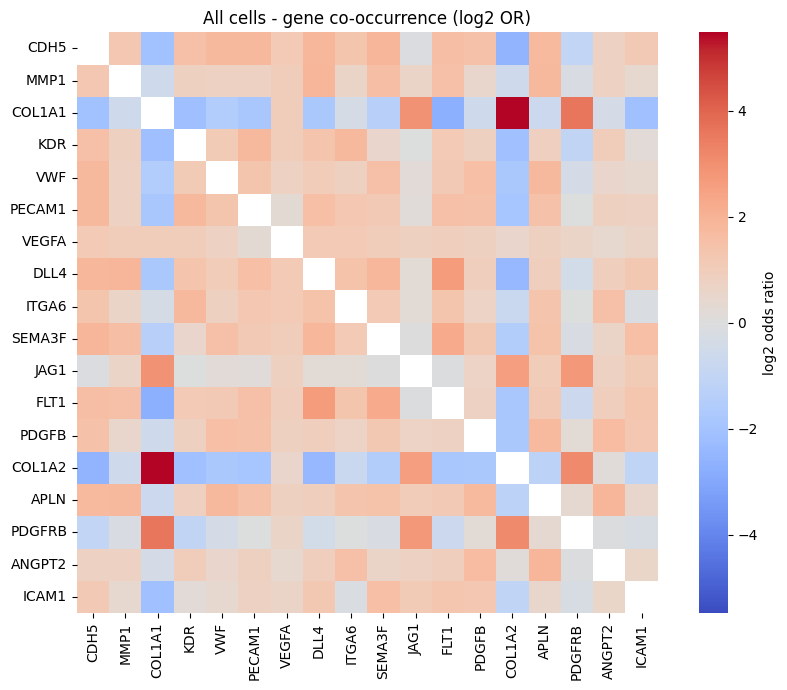

Significant pairs (FDR<0.05): 123  (co-occurring: 101, exclusive: 22)

Most significant co-occurring gene pairs:


,gene1,gene2,# cells gene1 on,# cells gene2 on,# overlap (both on),# overlap expected,odds_ratio,log2_OR,FDR
43,COL1A1,COL1A2,608,509,278,23.719782,44.439079,5.473757,2.855165e-252
2,CDH5,KDR,4889,3548,1981,1329.514218,2.864849,1.518459,2.547955e-149
3,CDH5,VWF,4889,2269,1403,850.244577,3.387900,1.760391,1.122826e-146
4,CDH5,PECAM1,4889,1960,1225,734.455430,3.375395,1.755056,5.946295e-130
49,KDR,PECAM1,3548,1960,994,533.002223,3.437354,1.781298,1.206684e-127
6,CDH5,DLL4,4889,1393,913,521.987967,3.671052,1.876194,2.521302e-110
101,DLL4,FLT1,1393,721,278,76.979612,6.311400,2.657960,1.171710e-91
5,CDH5,VEGFA,4889,3845,1950,1440.806699,2.192632,1.132664,6.604292e-88
8,CDH5,SEMA3F,4889,922,619,345.493830,3.754721,1.908706,1.601486e-78
22,MMP1,DLL4,1178,1393,317,125.772515,3.695189,1.885648,1.482674e-60


Most significant mutually-exclusive gene pairs:


,gene1,gene2,# cells gene1 on,# cells gene2 on,# overlap (both on),# overlap expected,odds_ratio,log2_OR,FDR
12,CDH5,COL1A2,4889,509,48,190.733579,0.167086,-2.581338,1.342468e-47
1,CDH5,COL1A1,4889,608,78,227.831072,0.234608,-2.091676,1.026105e-42
33,COL1A1,KDR,608,3548,48,165.339465,0.220978,-2.178025,1.859079e-33
57,KDR,COL1A2,3548,509,41,138.417414,0.228087,-2.132343,1.460748e-27
35,COL1A1,PECAM1,608,1960,30,91.337472,0.287018,-1.800788,4.920342e-15
70,VWF,COL1A2,2269,509,30,88.520043,0.292534,-1.773324,2.565429e-14
34,COL1A1,VWF,608,2269,42,105.737104,0.343956,-1.539702,5.261975e-14
82,PECAM1,COL1A2,1960,509,23,76.465088,0.264308,-1.919707,5.414428e-14
103,DLL4,COL1A2,1393,509,11,54.344830,0.186164,-2.425355,3.267477e-13
37,COL1A1,DLL4,608,1393,21,64.914846,0.295099,-1.760729,8.418605e-11


In [10]:
#  Full population (all cells, incl. all-0 and unknown lineage)
res_all, M_all = pairwise_cooccurrence(
    all_data, genes, title="All cells - gene co-occurrence (log2 OR)")
plt.tight_layout(); plt.show()

show_cols = {
    "gene1": "gene1", "gene2": "gene2",
    "n1": "# cells gene1 on", "n2": "# cells gene2 on",
    "both": "# overlap (both on)", "expected": "# overlap expected",
    "odds_ratio": "odds_ratio", "log2_OR": "log2_OR", "FDR": "FDR",
}
cols = list(show_cols)

sig = res_all[res_all.FDR < 0.05].copy()
sig.to_csv("all_cells_sig_pairs.csv")
print(f"Significant pairs (FDR<0.05): {len(sig)}  "
      f"(co-occurring: {(sig.log2_OR > 0).sum()}, exclusive: {(sig.log2_OR < 0).sum()})")
print("\nMost significant co-occurring gene pairs:")
display(sig[sig.log2_OR > 0].sort_values("FDR").head(10)[cols].rename(columns=show_cols))
print("Most significant mutually-exclusive gene pairs:")
display(sig[sig.log2_OR < 0].sort_values("FDR").head(10)[cols].rename(columns=show_cols))

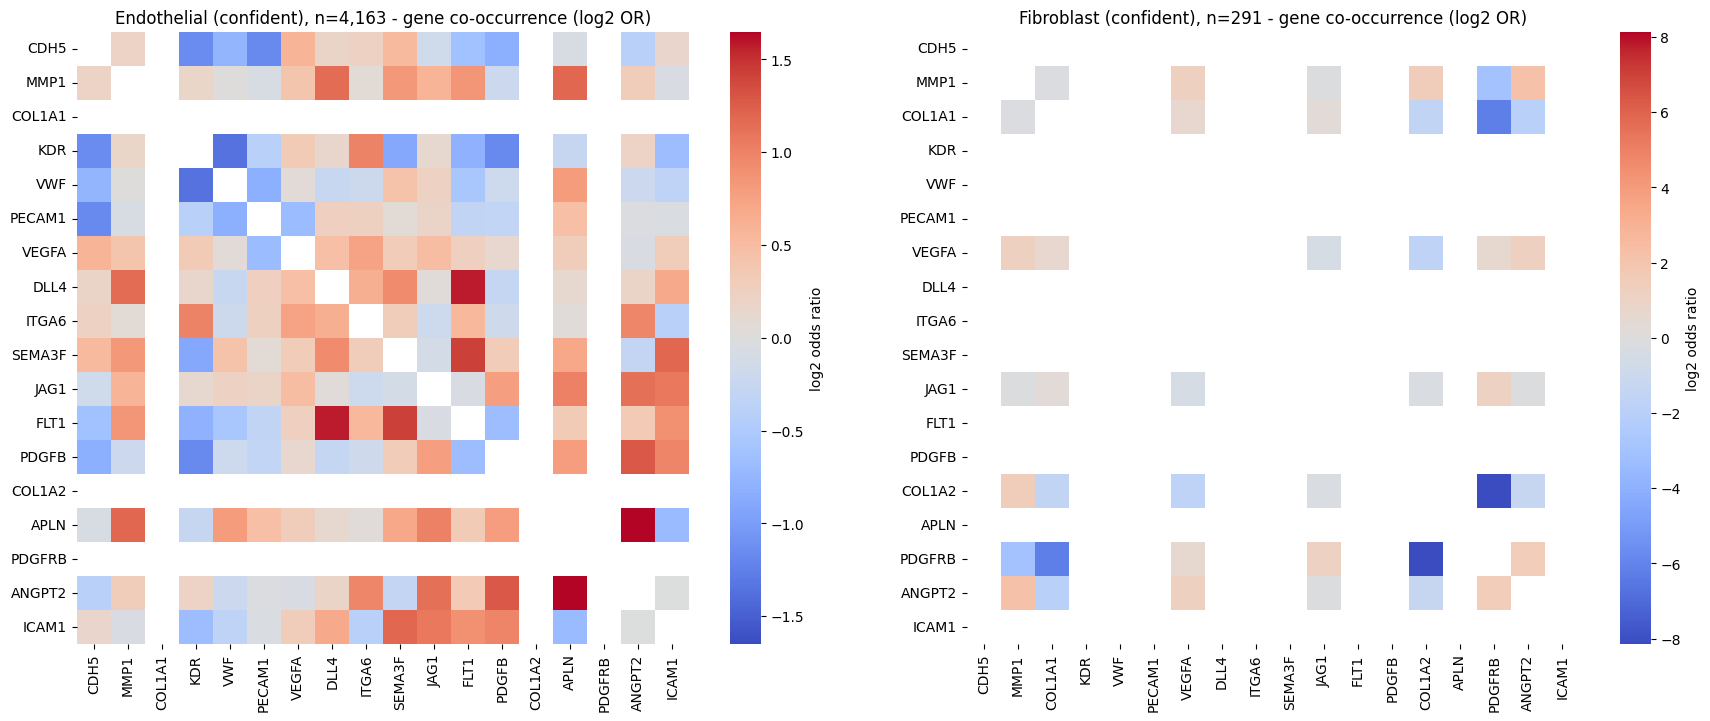

In [11]:
# Within-lineage co-occurrence WITHOUT circularity - use CONFIDENT cells only.
# A confident cell expresses >=2 of its lineage's markers and NONE of the other's, so
# the opposite lineage's markers are all-zero here and their pairs are simply not
# testable. The third panel uses ALL cells (incl. Unknown and Zero Reads) as the
# full-population reference.
subsets = {
    "endothelial": all_data[(all_data["cell_type"] == "Endothelial") & (all_data["confident"] == "Confident")],
    "fibroblast":  all_data[(all_data["cell_type"] == "Fibroblast") & (all_data["confident"] == "Confident")],
}
titles = {
    "endothelial": "Endothelial (confident)",
    "fibroblast":  "Fibroblast (confident)",
}
fig, axes = plt.subplots(1, len(subsets), figsize=(9 * len(subsets), 7))
lineage_res = {}
for ax, (key, sub) in zip(axes, subsets.items()):
    res, M = pairwise_cooccurrence(
        sub, genes, ax=ax,
        title=f"{titles[key]}, n={len(sub):,} - gene co-occurrence (log2 OR)")
    lineage_res[key] = res
plt.tight_layout(); plt.show()

In [12]:
# Significant within-lineage pairs (confident cells only).
# CAVEAT: a "confident" cell is selected on >=2 of its own markers, which makes those
# defining markers artificially anti-correlate within the subset (collider / Berkson
# bias). So pairs where BOTH genes are that lineage's markers are NOT interpretable -
# we flag them and report the trustworthy (non-marker) pairs separately.
lineage_markers = {"endothelial": set(endo_genes), "fibroblast": set(fibro_genes)}

for lineage in ["endothelial", "fibroblast"]:
    res = lineage_res[lineage].copy()
    mk = lineage_markers[lineage]
    res["both_defining"] = res.gene1.isin(mk) & res.gene2.isin(mk)
    testable = res[res.testable]
    trust = testable[~testable.both_defining]          # interpretable pairs
    biased = testable[testable.both_defining]          # collider-biased, do not interpret
    sig = trust[trust.FDR < 0.05]
    print(f"{lineage}: {len(testable)} testable pairs "
          f"({len(trust)} interpretable, {len(biased)} defining-marker pairs excluded); "
          f"{len(sig)} interpretable & significant (FDR<0.05)  "
          f"(co-occurring: {(sig.log2_OR > 0).sum()}, exclusive: {(sig.log2_OR < 0).sum()})")
    print("  most significant co-occurring (non-marker pairs):")
    display(sig[sig.log2_OR > 0].sort_values("FDR").head(10)[cols].rename(columns=show_cols))
    print("  most significant mutually-exclusive (non-marker pairs):")
    display(sig[sig.log2_OR < 0].sort_values("FDR").head(10)[cols].rename(columns=show_cols))
    if len(biased):
        print("  defining-marker pairs (collider-biased, NOT interpreted):")
        display(biased[cols].rename(columns=show_cols))

endothelial: 105 testable pairs (90 interpretable, 15 defining-marker pairs excluded); 28 interpretable & significant (FDR<0.05)  (co-occurring: 25, exclusive: 3)
  most significant co-occurring (non-marker pairs):


,gene1,gene2,# cells gene1 on,# cells gene2 on,# overlap (both on),# overlap expected,odds_ratio,log2_OR,FDR
101,DLL4,FLT1,885,612,243,130.103291,2.984213,1.577350,7.203636e-28
118,SEMA3F,FLT1,550,612,154,80.855153,2.681724,1.423161,7.048073e-17
22,MMP1,DLL4,599,885,206,127.339659,2.228471,1.156054,1.264766e-14
99,DLL4,SEMA3F,885,550,175,116.922892,1.909963,0.933545,6.726080e-09
141,PDGFB,ANGPT2,690,262,81,43.425414,2.425677,1.278388,2.839330e-08
26,MMP1,FLT1,599,612,132,88.058612,1.819389,0.863454,1.809007e-06
5,CDH5,VEGFA,3306,1704,1418,1353.212587,1.498318,0.583344,3.503819e-06
24,MMP1,SEMA3F,599,550,118,79.137641,1.782490,0.833894,1.059802e-05
148,APLN,ANGPT2,160,262,26,10.069661,3.138670,1.650154,4.018940e-05
124,SEMA3F,ICAM1,550,182,45,24.045160,2.275777,1.186359,1.154112e-04


  most significant mutually-exclusive (non-marker pairs):


,gene1,gene2,# cells gene1 on,# cells gene2 on,# overlap (both on),# overlap expected,odds_ratio,log2_OR,FDR
75,PECAM1,VEGFA,1655,1704,564,677.424934,0.620568,-0.688338,4.236346e-12
53,KDR,SEMA3F,2565,550,266,338.878213,0.535479,-0.901099,1.877358e-10
61,KDR,ICAM1,2565,182,92,112.137881,0.623342,-0.681904,9.983903e-03


  defining-marker pairs (collider-biased, NOT interpreted):


...

,gene1,gene2,# cells gene1 on,# cells gene2 on,# overlap (both on),# overlap expected,odds_ratio,log2_OR,FDR


  most significant mutually-exclusive (non-marker pairs):


,gene1,gene2,# cells gene1 on,# cells gene2 on,# overlap (both on),# overlap expected,odds_ratio,log2_OR,FDR


  defining-marker pairs (collider-biased, NOT interpreted):


,gene1,gene2,# cells gene1 on,# cells gene2 on,# overlap (both on),# overlap expected,odds_ratio,log2_OR,FDR
43,COL1A1,COL1A2,280,260,249,250.171821,0.344375,-1.537946,1.000000e+00
45,COL1A1,PDGFRB,280,78,67,75.051546,0.013746,-6.184839,2.269806e-05
144,COL1A2,PDGFRB,260,78,47,69.690722,0.003531,-8.145517,1.461939e-18


### Conclusions - pairwise gene interactions

**Approach.** For every gene pair we build a 2x2 on/off table, take the odds ratio, and
test it with Fisher's exact test (Benjamini-Hochberg FDR). Positive log2 OR = co-occur
more than chance; negative = mutually exclusive.

**Assumptions / drawbacks.** Cells are treated as independent. In the all-cells map the many
all-negative cells inflate positive odds ratios! Within a cell type, pairs of that cell type's
own markers are collider-biased and excluded.